# Weight Update Formula:
$$W_{new} = W_{old} + \eta * \frac{1}{m} (y - \hat {y})X $$

## Gradient of the Weight:
$$\frac{dL}{dW} = - \frac{1}{m} (y - \hat {y})X$$

In [15]:
from sklearn.datasets import make_classification
import numpy as np

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [96]:
X, y = make_classification(n_samples = 100, n_features = 2, n_informative = 1, n_redundant = 0, n_classes = 2, n_clusters_per_class = 1, random_state = 41, hypercube = False, class_sep = 20)

In [97]:
X.shape, y.shape

((100, 2), (100,))

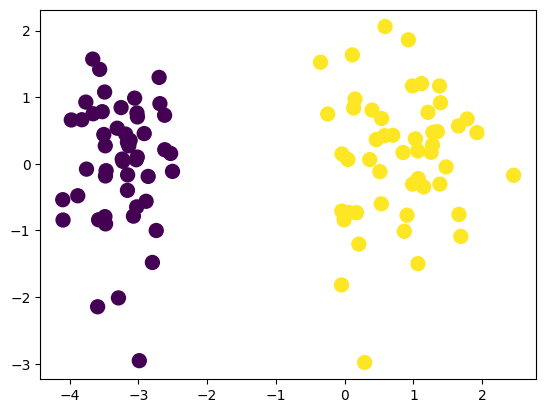

In [98]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'viridis', s = 100)
plt.show()

In [99]:
from sklearn.linear_model import LogisticRegression
logit_reg = LogisticRegression(penalty = None, solver = 'sag', verbose = 1)
logit_reg.fit(X, y)

max_iter reached after 0 seconds


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'sag'
,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",1
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [100]:
logit_reg.intercept_, logit_reg.coef_

(array([5.82749596]), array([[4.85618654, 0.21984136]]))

In [101]:
m1 = - (logit_reg.coef_[0][0] / logit_reg.coef_[0][1])
b1 = - (logit_reg.intercept_/logit_reg.coef_[0][1])
m1,b1

(np.float64(-22.089504045294902), array([-26.50773286]))

In [102]:
x_input = np.linspace(-3, 3, 100)
y_input = m1*x_input + b1

In [103]:
y_input

array([ 39.76077927,  38.42202145,  37.08326363,  35.74450581,
        34.40574799,  33.06699017,  31.72823235,  30.38947453,
        29.05071671,  27.71195888,  26.37320106,  25.03444324,
        23.69568542,  22.3569276 ,  21.01816978,  19.67941196,
        18.34065414,  17.00189632,  15.6631385 ,  14.32438068,
        12.98562285,  11.64686503,  10.30810721,   8.96934939,
         7.63059157,   6.29183375,   4.95307593,   3.61431811,
         2.27556029,   0.93680247,  -0.40195535,  -1.74071318,
        -3.079471  ,  -4.41822882,  -5.75698664,  -7.09574446,
        -8.43450228,  -9.7732601 , -11.11201792, -12.45077574,
       -13.78953356, -15.12829138, -16.46704921, -17.80580703,
       -19.14456485, -20.48332267, -21.82208049, -23.16083831,
       -24.49959613, -25.83835395, -27.17711177, -28.51586959,
       -29.85462741, -31.19338524, -32.53214306, -33.87090088,
       -35.2096587 , -36.54841652, -37.88717434, -39.22593216,
       -40.56468998, -41.9034478 , -43.24220562, -44.58

In [104]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [105]:
def GD(X, y):
    X = np.insert(X, 0, 1, axis = 1)
    weights = np.ones(X.shape[1])
    eta = 2.549

    for i in range(1000):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + eta*(np.dot((y - y_hat), X)/ X.shape[0])

    return weights[0], weights[1:]

In [106]:
b, m = GD(X, y)

In [107]:
logit_reg.intercept_

array([5.82749596])

In [108]:
logit_reg.coef_

array([[4.85618654, 0.21984136]])

In [109]:
m2 = - (m[0] / m[1])
b2 = - (b/m[1])
m2,b2

(np.float64(-22.776116422888432), np.float64(-27.47103779489519))

In [110]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m2*x_input + b2

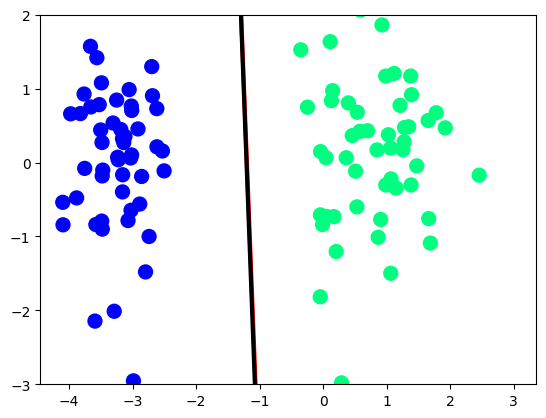

In [116]:
plt.scatter(X[:,0], X[:,1], c = y, cmap = 'winter', s = 100)
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.ylim(-3,2)


plt.show()